## Initial Setup

In [21]:
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import make_grid
from tqdm import tqdm
import logging
import warnings
import h5py
import random


## wy add
import sys
sys.path.append('../Misc')


# Import custom modules
from data_manage import HDF5ImageGenerator  
from modules import EMA, UNet_conditional_conv   

# Set up matplotlib for inline display
%matplotlib inline

#Suppresses one irrelevant PyTorch warning to not clutter the notebook:

#(Minor security warning that only matteres if we are loading model files from untrusted sources, which is not the case here)
warnings.filterwarnings('ignore', category=FutureWarning, message='You are using `torch.load`.*')



## Essential Setting

In [22]:
config = {
    # Generation Settings
    'num_images': 10,          # How many galaxies to generate
    'use_fixed_seed': False,   # Set True to use specific seed value， fix random seed?
    'seed': None,             # Set to a number to use that specific seed
    'random_redshifts': True,  # True for random redshifts, False for linear spacing  
    
    # Display Settings
    'use_cmap': True,         # True for heatmap, False for grayscale
    'cmap': 'inferno',        # Good options: 'magma', 'inferno', 'viridis', 'hot'
    
    # Quality Control Settings
    'max_std': 0.25,          # Noise filtering threshold； large std: high noise, random pixel values
    'skip_filtering': False,   # Set True to disable noise filtering
    
    # Model Path

    'model_dir': '../Training/Model_Checkpoints_wy',
    # 'model_dir': './Model_Checkpoints',
    'model_name': 'best_model.pth'
}
# Verify model path
model_path = os.path.join(config['model_dir'], config['model_name'])
if not os.path.exists(model_path):
    raise FileNotFoundError(f"Model checkpoint not found at: {model_path}")
print(f"Found model checkpoint at: {model_path}")

Found model checkpoint at: ../Training/Model_Checkpoints_wy/best_model.pth


## 🎲 Random Seeds and Image Generation

In [23]:
# Device configuration and initial seed setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Seed handling
if config['use_fixed_seed'] and config['seed'] is not None:
    seed_to_use = config['seed']
    print(f"Using fixed seed: {seed_to_use}")
else:
    seed_to_use = random.randint(0, 1000000)
    print(f"Using random seed: {seed_to_use}")

# Apply the seed to both torch and numpy
torch.manual_seed(seed_to_use)
np.random.seed(seed_to_use)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed_to_use)

Using device: cpu
Using random seed: 919551


## Image Processing

In [24]:
def denormalize_images(images):
    """Converts images from model format (-1 to 1) to viewable format (0 to 1)"""
    return (images + 1) / 2

## The Denoising Diffusion Probabilistic Model

In [25]:
class Diffusion:
    def __init__(self, noise_steps=1000, beta_start=1e-4, beta_end=0.02, img_size=64, device="cuda"):
        self.noise_steps = noise_steps
        self.beta_start = beta_start
        self.beta_end = beta_end
        self.beta = self.prepare_noise_schedule().to(device)
        self.alpha = 1. - self.beta
        self.alpha_hat = torch.cumprod(self.alpha, dim=0)
        self.img_size = img_size
        self.device = device

    def prepare_noise_schedule(self):
        # wy change，change to linearly add noise
        return torch.linspace(self.beta_start, self.beta_end, self.noise_steps)
    

    # def prepare_noise_schedule(self):
    #     """Prepares a cosine noise schedule for the diffusion process."""
    #     steps = torch.linspace(0, self.noise_steps, self.noise_steps)
    #     schedule = torch.cos((steps / self.noise_steps) * (torch.pi / 2))
    #     beta = self.beta_start + (self.beta_end - self.beta_start) * (1 - schedule)
    #     return beta

    def sample_images(self, model, n, labels):
        """Generates n galaxy images based on given redshift labels with a progress bar."""
        model.eval()
        with torch.no_grad():
            # Initialize starting noise for the images
            x = torch.randn((n, 5, self.img_size, self.img_size)).to(self.device)
            
            # Ensure labels are shaped correctly
            labels = labels.view(-1, 1) if labels.dim() == 1 else labels
            
            # Progress bar for the diffusion process
            for i in tqdm(reversed(range(1, self.noise_steps)), desc="Generating Images", total=self.noise_steps):
                t = (torch.ones(n) * i).long().to(self.device)
                predicted_noise = model(x, t, labels)
                
                # Calculate alphas and betas for the diffusion step
                alpha = self.alpha[t][:, None, None, None]
                alpha_hat = self.alpha_hat[t][:, None, None, None]
                beta = self.beta[t][:, None, None, None]
                
                # Sample noise at each step, except for the last step
                noise = torch.randn_like(x) if i > 1 else torch.zeros_like(x)
                
                # Update x with predicted noise and diffusion process adjustments
                x = 1 / torch.sqrt(alpha) * (x - ((1 - alpha) / torch.sqrt(1 - alpha_hat)) * predicted_noise) + torch.sqrt(beta) * noise

        model.train()
        return x

## 🔍 Image Quality Control

In [26]:
def filter_and_replace_noisy_images(images, max_std=0.25, skip_filtering=False):
    """
    Removes overly noisy images and replaces them with good ones.
    
    Args:
        images: Image tensor to filter
        max_std: Maximum standard deviation threshold (default: from config or 0.25)
        skip_filtering: If True, returns images unfiltered (default: from config or False)
    """
    if skip_filtering:
        return images
    
    good_images = [img for img in images if img.std().item() < max_std]
    while len(good_images) < images.size(0):
        good_images.extend(good_images)
    good_images = good_images[:images.size(0)]
    return torch.stack(good_images)

def plot_all_channels(images, num_images, max_std=None, cmap=None, use_cmap=None, skip_filtering=None, redshifts=None):
    """
    Plots all 5 channels (g, r, i, z, y) with option for colormap or grayscale.
    
    Args:
        images: Image tensor of shape (N, 5, H, W)
        num_images: Number of images to display
        max_std: Maximum standard deviation for noise filtering (default: from config)
        cmap: Colormap to use (default: from config)
        use_cmap: If True, uses colormap (default: from config)
        skip_filtering: If True, disables noise filtering (default: from config)
        redshifts: Tensor of redshift values for each image
    """
    # Use config settings if not explicitly provided
    max_std = config['max_std'] if max_std is None else max_std
    cmap = config['cmap'] if cmap is None else cmap
    use_cmap = config['use_cmap'] if use_cmap is None else use_cmap
    skip_filtering = config['skip_filtering'] if skip_filtering is None else skip_filtering
    
    # Filter images if enabled
    images = filter_and_replace_noisy_images(images, max_std, skip_filtering)
    num_images = min(num_images, images.size(0))
    num_channels = images.size(1)
    
    # Create figure and grid
    fig = plt.figure(figsize=(num_images * 3, num_channels * 2.5))
    gs = fig.add_gridspec(num_channels, num_images, left=0.015, right=0.98, 
                         top=0.95, bottom=0.05, wspace=0.1, hspace=0.1)
    
    axs = [[fig.add_subplot(gs[i, j]) for j in range(num_images)] for i in range(num_channels)]
    channel_names = ['g', 'r', 'i', 'z', 'y']
    
    # Plot each channel
    for channel_idx in range(num_channels):
        for img_idx in range(num_images):
            channel_data = images[img_idx, channel_idx].cpu().numpy()
            
            # Safe normalization
            channel_min = channel_data.min()
            channel_max = channel_data.max()
            if channel_max - channel_min > 1e-10:  # Check if range is non-zero
                channel_data = (channel_data - channel_min) / (channel_max - channel_min)
            else:
                channel_data = np.full_like(channel_data, 0.5)
            
            axs[channel_idx][img_idx].imshow(channel_data, 
                                           cmap=cmap if use_cmap else 'gray')
            axs[channel_idx][img_idx].axis('off')
            
            if channel_idx == 0:
                if redshifts is not None:
                    title = f"redshift = {redshifts[img_idx].item():.2f}"
                else:
                    title = f"Image {img_idx + 1}"
                axs[channel_idx][img_idx].set_title(title)
            
            if img_idx == 0:
                fig.text(0.01, 0.85 - (channel_idx * 0.195), channel_names[channel_idx], 
                        ha='left', va='center', fontsize=14, fontweight='bold')
    plt.show()

def plot_rgb_channels(images, num_images, max_std=None, skip_filtering=None, redshifts=None):
    """
    Plots images using g, r, i channels combined into RGB display.
    
    Args:
        images: Image tensor of shape (N, 5, H, W)
        num_images: Number of images to display
        max_std: Maximum standard deviation for filtering (default: from config)
        skip_filtering: If True, skips filtering (default: from config)
        redshifts: Tensor of redshift values for each image
    """
    # Use config settings if not explicitly provided
    max_std = config['max_std'] if max_std is None else max_std
    skip_filtering = config['skip_filtering'] if skip_filtering is None else skip_filtering
    
    # Filter images if enabled
    images = filter_and_replace_noisy_images(images, max_std, skip_filtering)
    num_images = min(num_images, images.size(0))
    
    # Calculate grid layout
    rows = (num_images // 6) + (1 if num_images % 6 else 0)
    fig, axs = plt.subplots(rows, 6, figsize=(16, rows * 4))
    axs = axs.flatten()
    
    for idx, ax in enumerate(axs):
        if idx >= num_images:
            ax.axis('off')
            continue
        
        # Combine g, r, i channels into RGB
        rgb_image = torch.stack([
            images[idx, 0],  # g -> Red channel
            images[idx, 1],  # r -> Green channel
            images[idx, 2]   # i -> Blue channel
        ], dim=0)
        
        # Normalize and convert to numpy
        rgb_image = rgb_image.permute(1, 2, 0).cpu().numpy()
        
        # Safe normalization for RGB image
        img_min = rgb_image.min()
        img_max = rgb_image.max()
        if img_max - img_min > 1e-10:  # Check if range is non-zero
            rgb_image = (rgb_image - img_min) / (img_max - img_min)
        else:
            rgb_image = np.full_like(rgb_image, 0.5)
        
        # Plot
        ax.imshow(rgb_image)
        ax.axis('off')
        
        if redshifts is not None:
            title = f"redshift = {redshifts[idx].item():.2f}"
        else:
            title = f"Image #{idx+1}"
        ax.set_title(title)
    
    plt.tight_layout()
    plt.show()

## 🛠️ Model Configuration

In [27]:
class Args:
    def __init__(self):
        self.device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
        self.image_size = 64    # Size of generated images
        self.noise_steps = 1000  # Steps in diffusion process
        self.beta_start = 1e-4   # Starting noise level
        self.beta_end = 0.02     # Ending noise level

args = Args()

In [28]:
# Initialize model first
model = UNet_conditional_conv(
    c_in=5,  # g,r,i,z,y channels
    c_out=5,
    time_dim=256,
    y_dim=1  # For redshift conditioning
).to(args.device)

# Load the checkpoint and extract model state dict
checkpoint = torch.load(model_path, map_location=args.device, weights_only=False)
#checkpoint = torch.load(model_path, map_location=args.device)
model.load_state_dict(checkpoint['model_state_dict'])   

# Initialize EMA
ema = EMA(model, beta=0.995)
# Load EMA state if it exists in checkpoint
if 'ema_state_dict' in checkpoint:
    ema.load_state_dict(checkpoint['ema_state_dict'])

## Galaxy Generation

In [29]:
# Initialize the diffusion process with specified noise settings
diffusion = Diffusion(
    noise_steps=args.noise_steps,
    beta_start=args.beta_start,
    beta_end=args.beta_end,
    img_size=args.image_size,
    device=args.device
)

# Define the redshift range for the images
redshift_min, redshift_max = 0.1, .5  # Modify these values to change galaxy properties
print(f"\nGenerating galaxies in redshift range: {redshift_min} to {redshift_max}")

# Create redshift values for conditioning based on config setting
if config['random_redshifts']:
    sample_redshifts = torch.rand(config['num_images'], 1).to(device) * (redshift_max - redshift_min) + redshift_min
    print(f"Generating {config['num_images']} galaxies with random redshifts...")
else:
    sample_redshifts = torch.linspace(redshift_min, redshift_max, config['num_images']).to(device).unsqueeze(1)
    print(f"Generating {config['num_images']} galaxies with linearly spaced redshifts...")

# Generate images with progress bar
with torch.no_grad():
    ema_model = ema.get_ema_model()
    generated_images = diffusion.sample_images(ema_model, config['num_images'], sample_redshifts)
print(f"Generated images shape: {generated_images.shape}")


Generating galaxies in redshift range: 0.1 to 0.5
Generating 10 galaxies with random redshifts...


Generating Images:   1%|▏         | 14/1000 [00:05<05:54,  2.78it/s]


KeyboardInterrupt: 

## 📊 Visualization and Analysis

Generated images shape: torch.Size([10, 5, 64, 64])

🎨 RGB Composite View (g, r, i channels combined) - Generated Images:


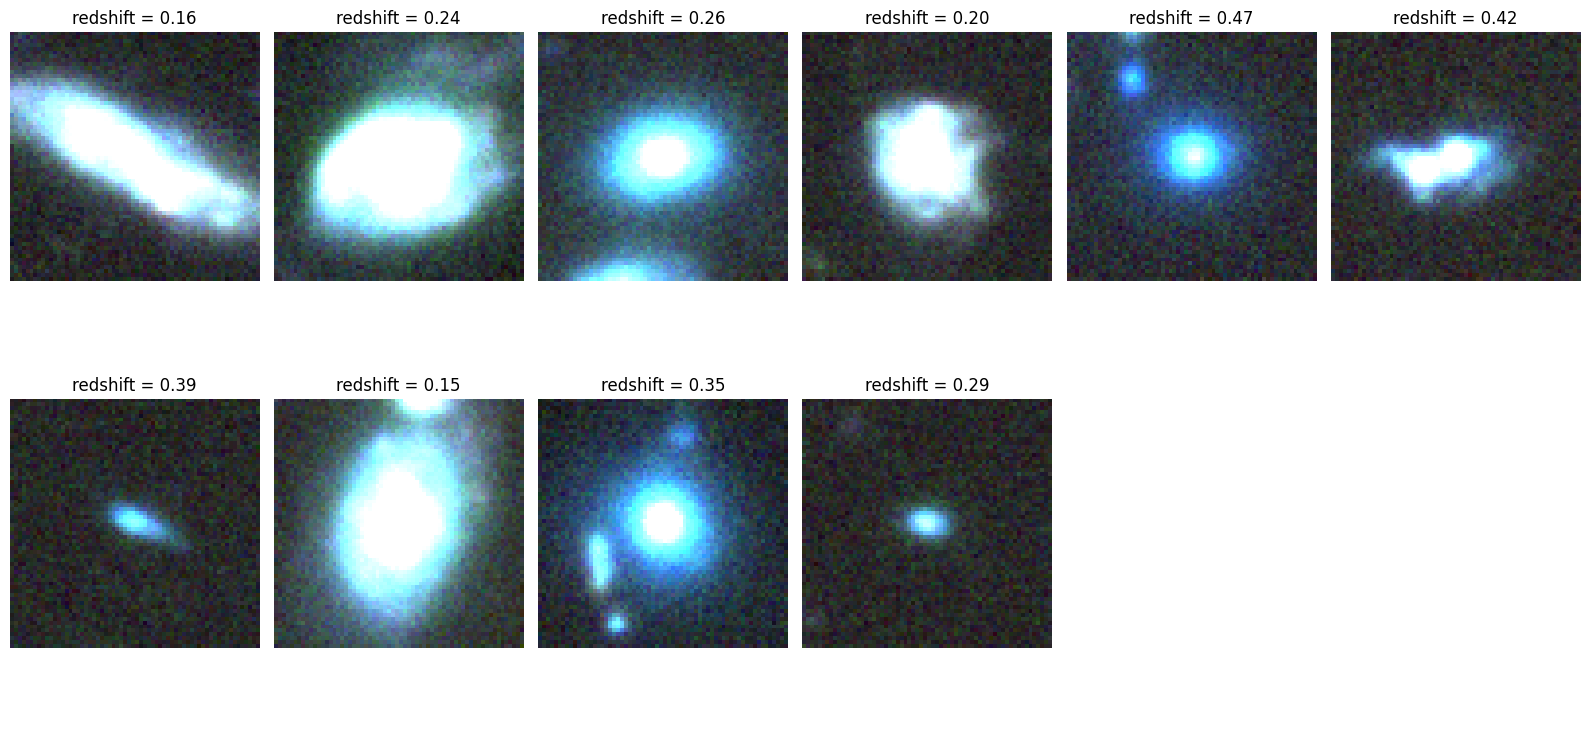


📊 Individual Channel View (g, r, i, z, y separately) - Generated Images:


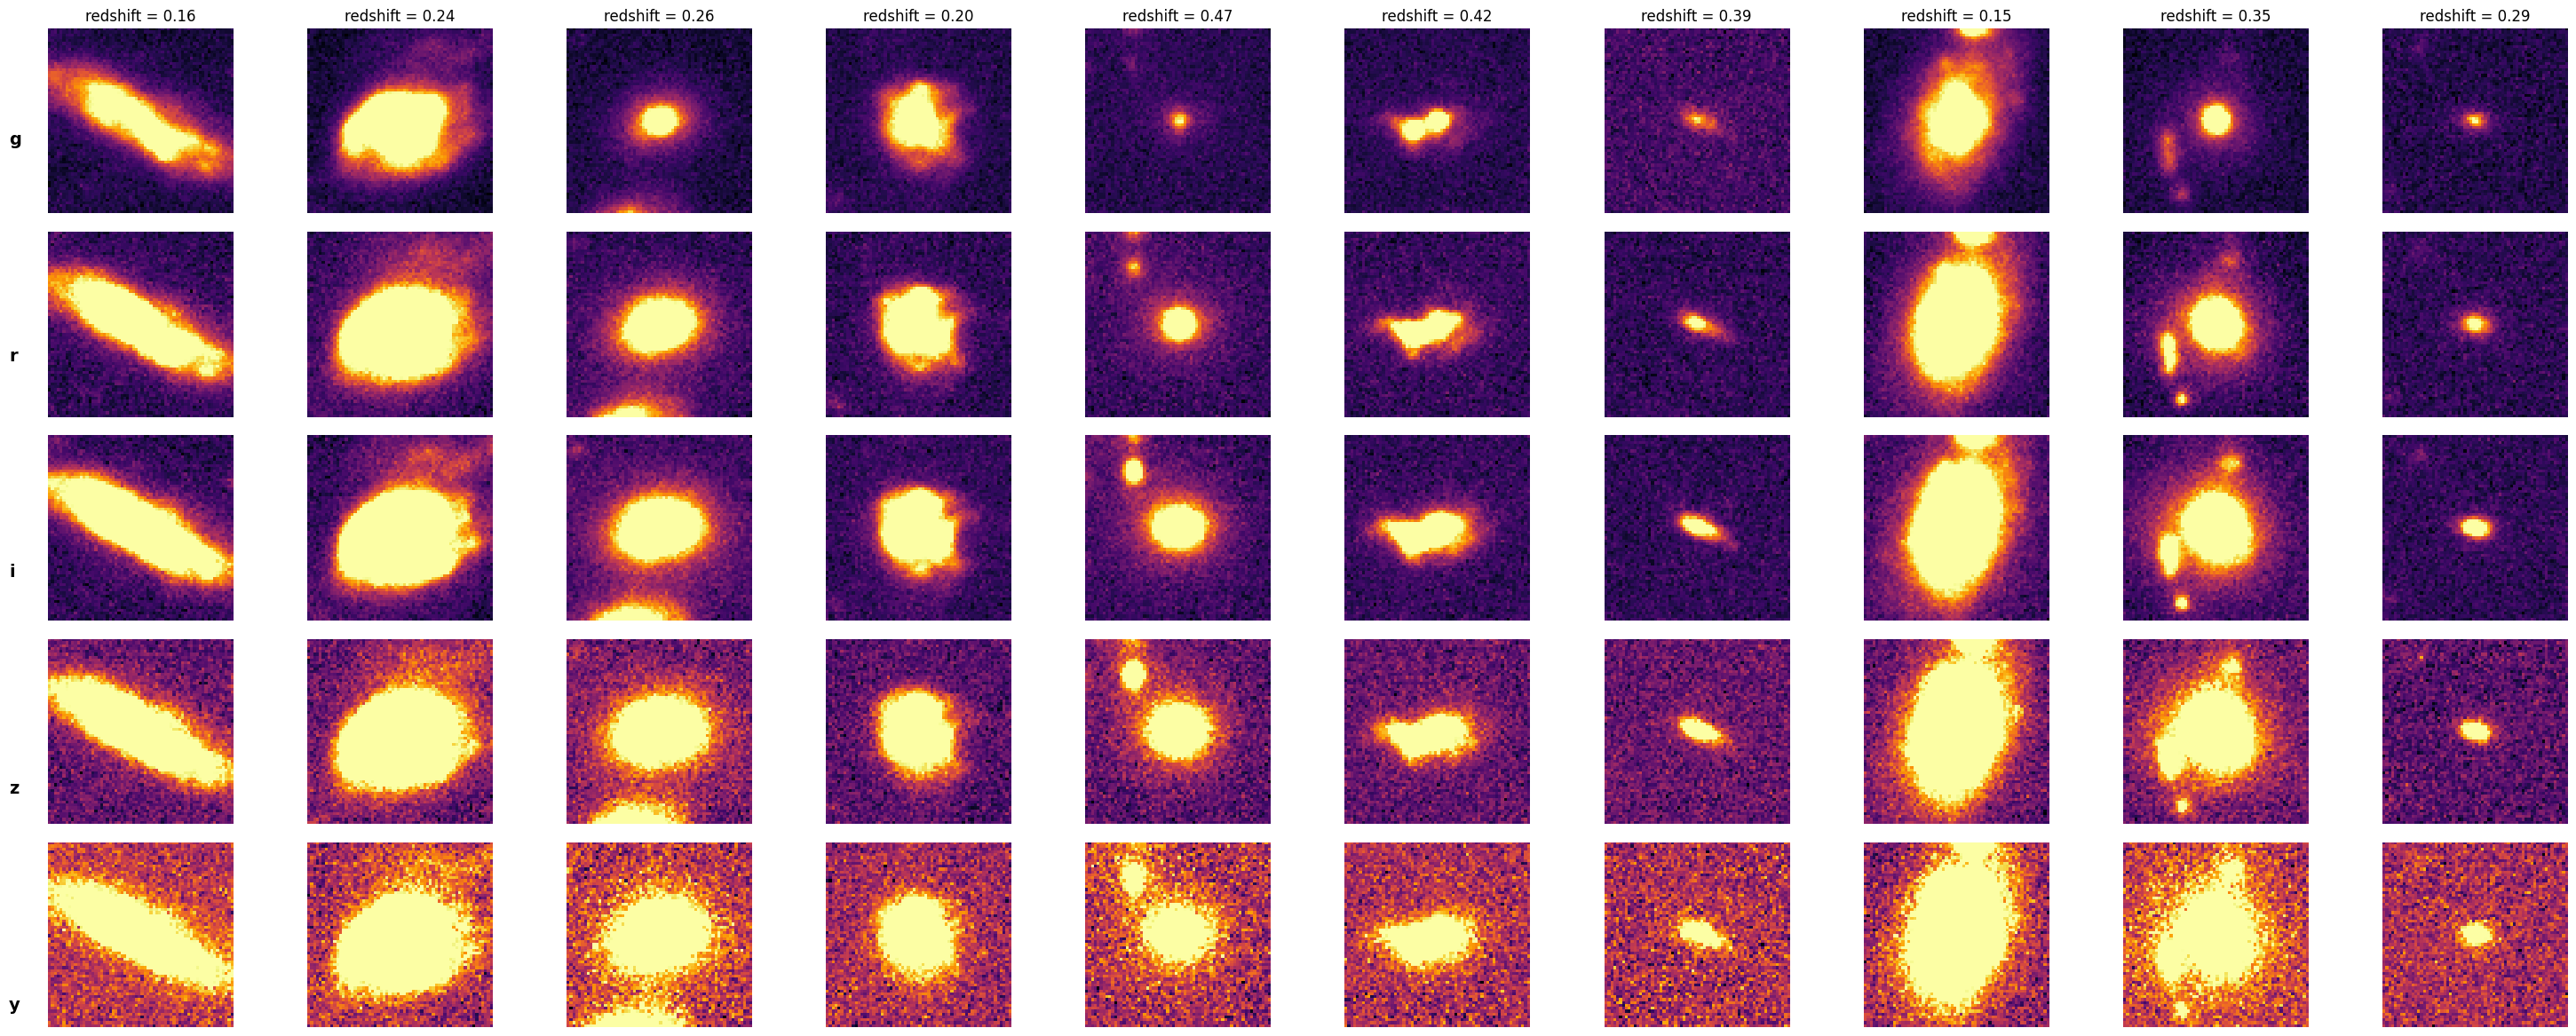


📊 Image Statistics - Generated Images:
Mean intensity: 0.6259
Standard deviation: 0.1772
Redshift range: 0.15 to 0.47

 Generation Settings:
  • Random Seed: 79346 (Random)
  • Redshift Distribution: Random
  • Redshift Range: 0.1 to 0.5

Display Settings:
  • Mode: Heatmap
  • Colormap: inferno

Quality Control:
  • Noise Filtering: Enabled
  • Filter Threshold: 0.25 (lower = stricter)

💡 Tip: Adjust these settings in the config section at the top of the notebook


In [ ]:
print(f"Generated images shape: {generated_images.shape}")

# Prepare images for display
generated_images_denorm = denormalize_images(generated_images)
generated_images_denorm = torch.clamp(generated_images_denorm, 0.0, 1.0)

# Display RGB composite view
print("\n🎨 RGB Composite View (g, r, i channels combined) - Generated Images:")
plot_rgb_channels(
    images=generated_images_denorm,
    num_images=config['num_images'],
    max_std=config['max_std'],
    skip_filtering=config['skip_filtering'],
    redshifts=sample_redshifts   
)

# Display individual channel view
print("\n📊 Individual Channel View (g, r, i, z, y separately) - Generated Images:")
plot_all_channels(
    images=generated_images_denorm,
    num_images=config['num_images'],
    max_std=config['max_std'],
    cmap=config['cmap'],
    use_cmap=config['use_cmap'],
    skip_filtering=config['skip_filtering'],
    redshifts=sample_redshifts   
)

# Display statistics and settings
print("\n📊 Image Statistics - Generated Images:")
print(f"Mean intensity: {generated_images_denorm.mean().item():.4f}")
print(f"Standard deviation: {generated_images_denorm.std().item():.4f}")
print(f"Redshift range: {sample_redshifts.min().item():.2f} to {sample_redshifts.max().item():.2f}")

print("\n Generation Settings:")
print(f"  • Random Seed: {seed_to_use} ({'Fixed' if config['use_fixed_seed'] else 'Random'})")
print(f"  • Redshift Distribution: {'Random' if config['random_redshifts'] else 'Linear'}")
print(f"  • Redshift Range: {redshift_min} to {redshift_max}")

print("\nDisplay Settings:")
print(f"  • Mode: {'Heatmap' if config['use_cmap'] else 'Grayscale'}")
print(f"  • Colormap: {config['cmap'] if config['use_cmap'] else 'N/A'}")

print("\nQuality Control:")
print(f"  • Noise Filtering: {'Disabled' if config['skip_filtering'] else 'Enabled'}")
print(f"  • Filter Threshold: {config['max_std']} (lower = stricter)")

print("\n💡 Tip: Adjust these settings in the config section at the top of the notebook")

## 📊 Visualize Real Images For Comparison

In [ ]:
def load_real_images(hdf5_path, num_images, redshift_min=None, redshift_max=None, random_redshifts=True, seed_to_use=None):
    """
    Load real images from HDF5 file with optional redshift filtering.
    """
    # Generate a completely new random seed for this specific selection
    selection_seed = random.randint(0, 1000000)
    np.random.seed(selection_seed)
     
    
    with h5py.File(hdf5_path, 'r') as f:
        total_images = f['image'].shape[0]
        all_redshifts = f['specz_redshift'][:]
        
        # Filter by redshift range
        valid_indices = np.where((all_redshifts >= redshift_min) & 
                               (all_redshifts <= redshift_max))[0]
        
        if len(valid_indices) == 0:
            raise ValueError(f"No images found in redshift range {redshift_min} to {redshift_max}")
        
        # Select images
        if random_redshifts:
            print("Using random selection")
            selected_indices = np.random.permutation(valid_indices)[:num_images]
        else:
            print("Using linear spacing with random selection at each redshift")
            target_redshifts = np.linspace(redshift_min, redshift_max, num_images)
            selected_indices = []
            
            for target_z in target_redshifts:
                # Find all images near this redshift
                redshift_diffs = np.abs(all_redshifts[valid_indices] - target_z)
                # Get the indices of the 10 closest matches
                closest_matches = np.argsort(redshift_diffs)[:10]  # Take 10 closest matches
                # Randomly select one from these matches
                selected_idx = valid_indices[closest_matches[np.random.randint(0, len(closest_matches))]]
                selected_indices.append(selected_idx)
            
            selected_indices = np.array(selected_indices)
        
        # Sort indices for HDF5 access
        sorted_idx = np.argsort(selected_indices)
        sorted_selected_indices = selected_indices[sorted_idx]
        
        # Load images and redshifts
        selected_images = f['image'][sorted_selected_indices]
        selected_redshifts = f['specz_redshift'][sorted_selected_indices]
        
        # Restore original order
        selected_images = selected_images[np.argsort(sorted_idx)]
        selected_redshifts = selected_redshifts[np.argsort(sorted_idx)]
        
        # Reset random seed to original value if one was provided
        if seed_to_use is not None:
            np.random.seed(seed_to_use)
            
        return torch.tensor(selected_images), torch.tensor(selected_redshifts)


Loading real galaxies in redshift range: 0.1 to 0.5
Using random selection

🎨 RGB Composite View (g, r, i channels combined) - Real Images:


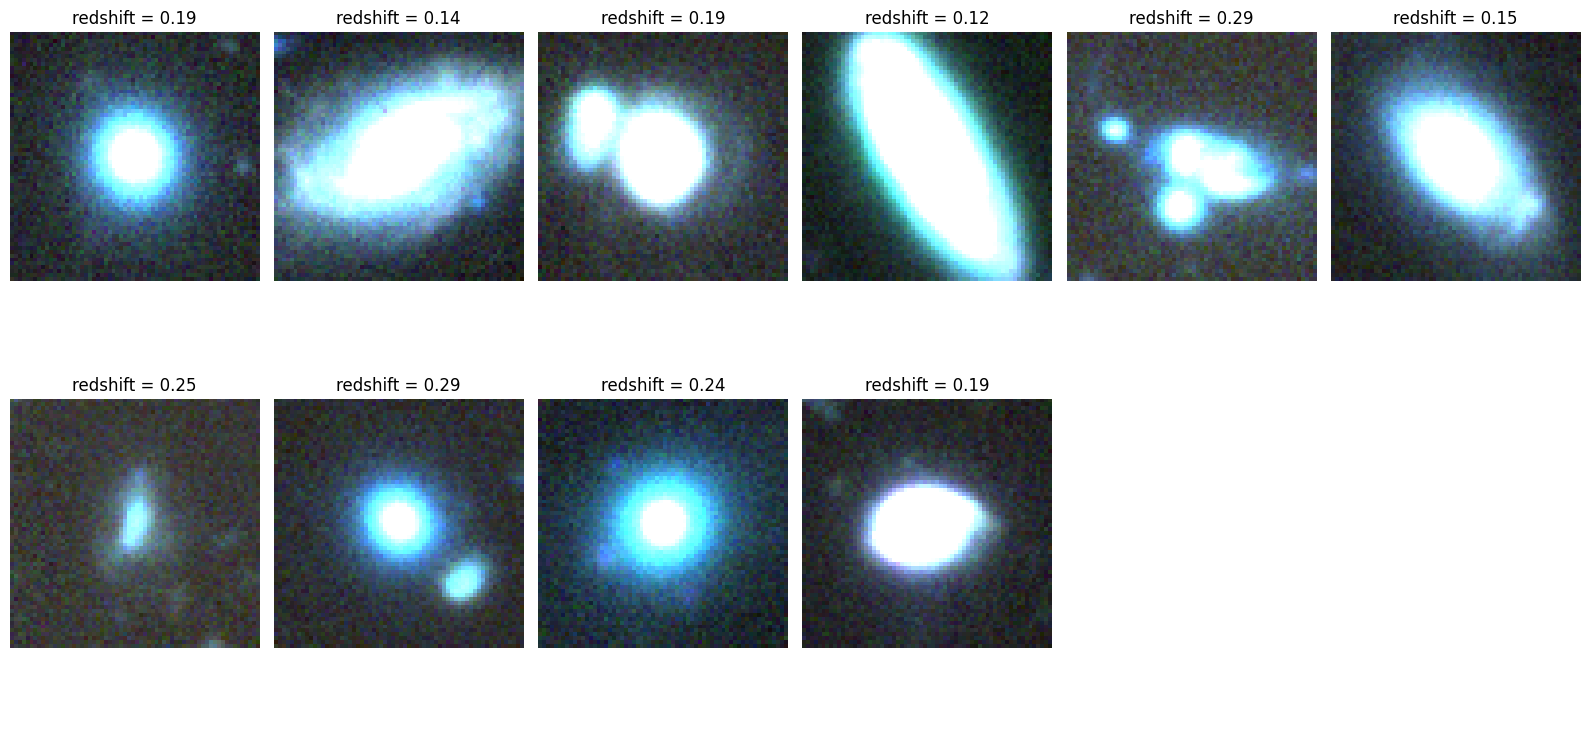


📊 Individual Channel View (g, r, i, z, y separately) - Real Images:


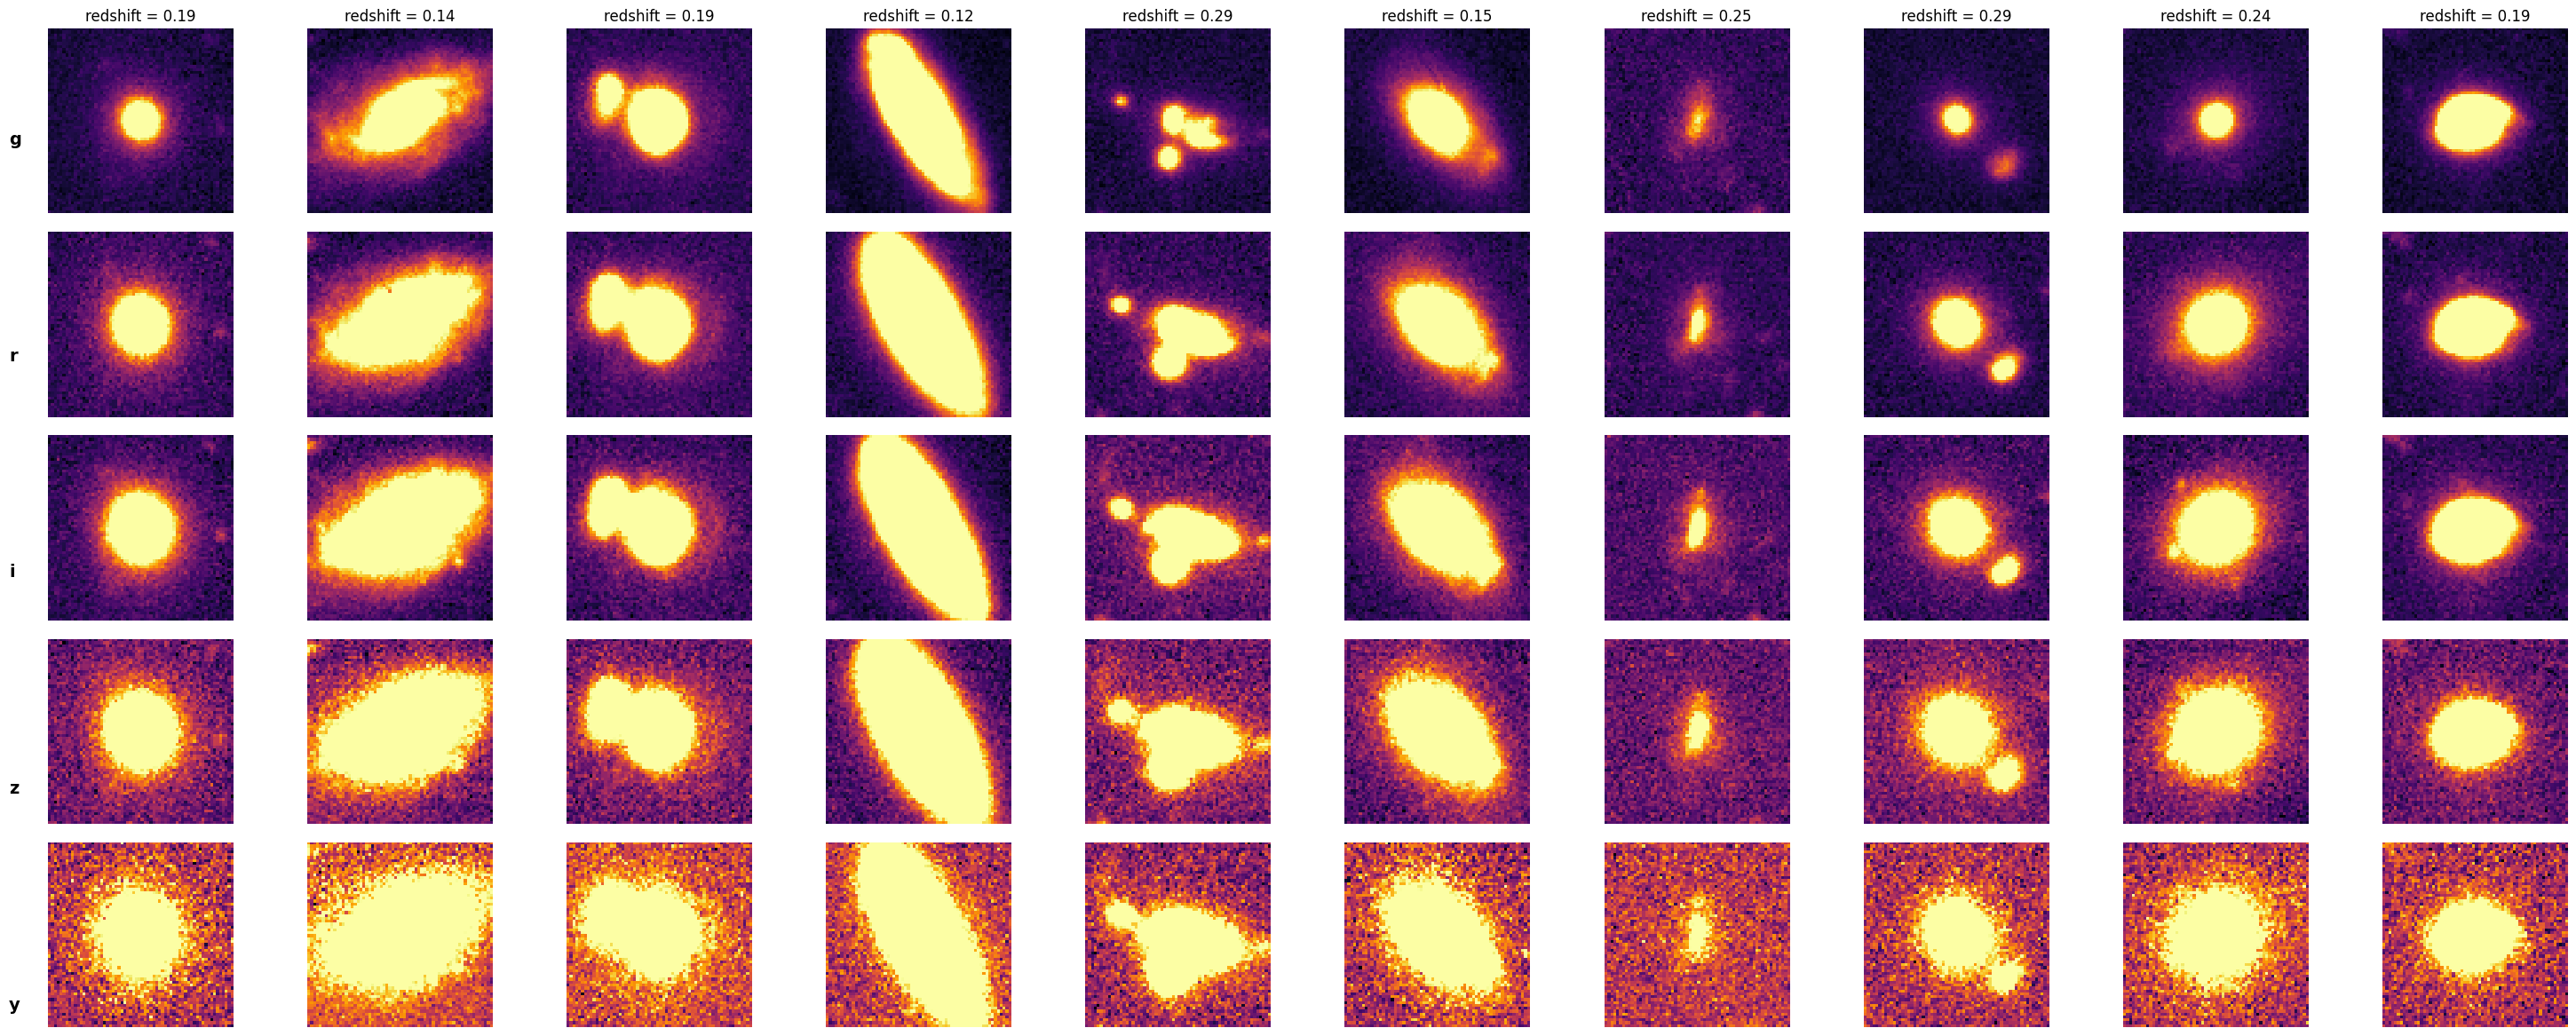


📊 Image Statistics - Real Images:
Mean intensity: 0.6578
Standard deviation: 0.1877
Redshift range: 0.12 to 0.29

 Current Settings for Real Images:
  • Redshift Distribution: Random
  • Redshift Range: 0.1 to 0.5

Display Settings:
  • Mode: Heatmap
  • Colormap: inferno

Quality Control:
  • Noise Filtering: Enabled
  • Filter Threshold: 0.25 (lower = stricter)


In [ ]:
# Define the path to the testing HDF5 file
testing_hdf5_path = '/Users/wen/Desktop/project/archive/5x64x64_testing_with_morphology.hdf5'
#testing_hdf5_path = '/shared/astrodata/5x64x64_testing_with_morphology.hdf5'

# Define redshift range (similar to generated images)
redshift_min, redshift_max = 0.1, .5

print(f"\nLoading real galaxies in redshift range: {redshift_min} to {redshift_max}")

try:
    real_images_tensor, real_redshifts = load_real_images(
        testing_hdf5_path,
        config['num_images'],
        redshift_min=redshift_min,
        redshift_max=redshift_max,
        random_redshifts=config['random_redshifts'],
        seed_to_use=seed_to_use
    )
    
    # Normalize the real images for display
    real_images_denorm = denormalize_images(real_images_tensor)
    real_images_denorm = torch.clamp(real_images_denorm, 0.0, 1.0)

    # Display RGB composite view for real images
    print("\n🎨 RGB Composite View (g, r, i channels combined) - Real Images:")
    plot_rgb_channels(
        images=real_images_denorm,
        num_images=config['num_images'],
        max_std=config['max_std'],
        skip_filtering=config['skip_filtering'],
        redshifts=real_redshifts
    )

    # Display individual channel view for real images
    print("\n📊 Individual Channel View (g, r, i, z, y separately) - Real Images:")
    plot_all_channels(
        images=real_images_denorm,
        num_images=config['num_images'],
        max_std=config['max_std'],
        cmap=config['cmap'],
        use_cmap=config['use_cmap'],
        skip_filtering=config['skip_filtering'],
        redshifts=real_redshifts
    )

    # Display statistics and settings for real images
    print("\n📊 Image Statistics - Real Images:")
    print(f"Mean intensity: {real_images_denorm.mean().item():.4f}")
    print(f"Standard deviation: {real_images_denorm.std().item():.4f}")
    print(f"Redshift range: {real_redshifts.min().item():.2f} to {real_redshifts.max().item():.2f}")
    
    print("\n Current Settings for Real Images:")
    print(f"  • Redshift Distribution: {'Random' if config['random_redshifts'] else 'Linear'}")
    print(f"  • Redshift Range: {redshift_min} to {redshift_max}")
    print("\nDisplay Settings:")
    print(f"  • Mode: {'Heatmap' if config['use_cmap'] else 'Grayscale'}")
    print(f"  • Colormap: {config['cmap'] if config['use_cmap'] else 'N/A'}")
    print("\nQuality Control:")
    print(f"  • Noise Filtering: {'Disabled' if config['skip_filtering'] else 'Enabled'}")
    print(f"  • Filter Threshold: {config['max_std']} (lower = stricter)")
    
except ValueError as e:
    print(f"Error: {e}")
    print("Please try a different redshift range.")

## Comparison between generated and test via diff redshift

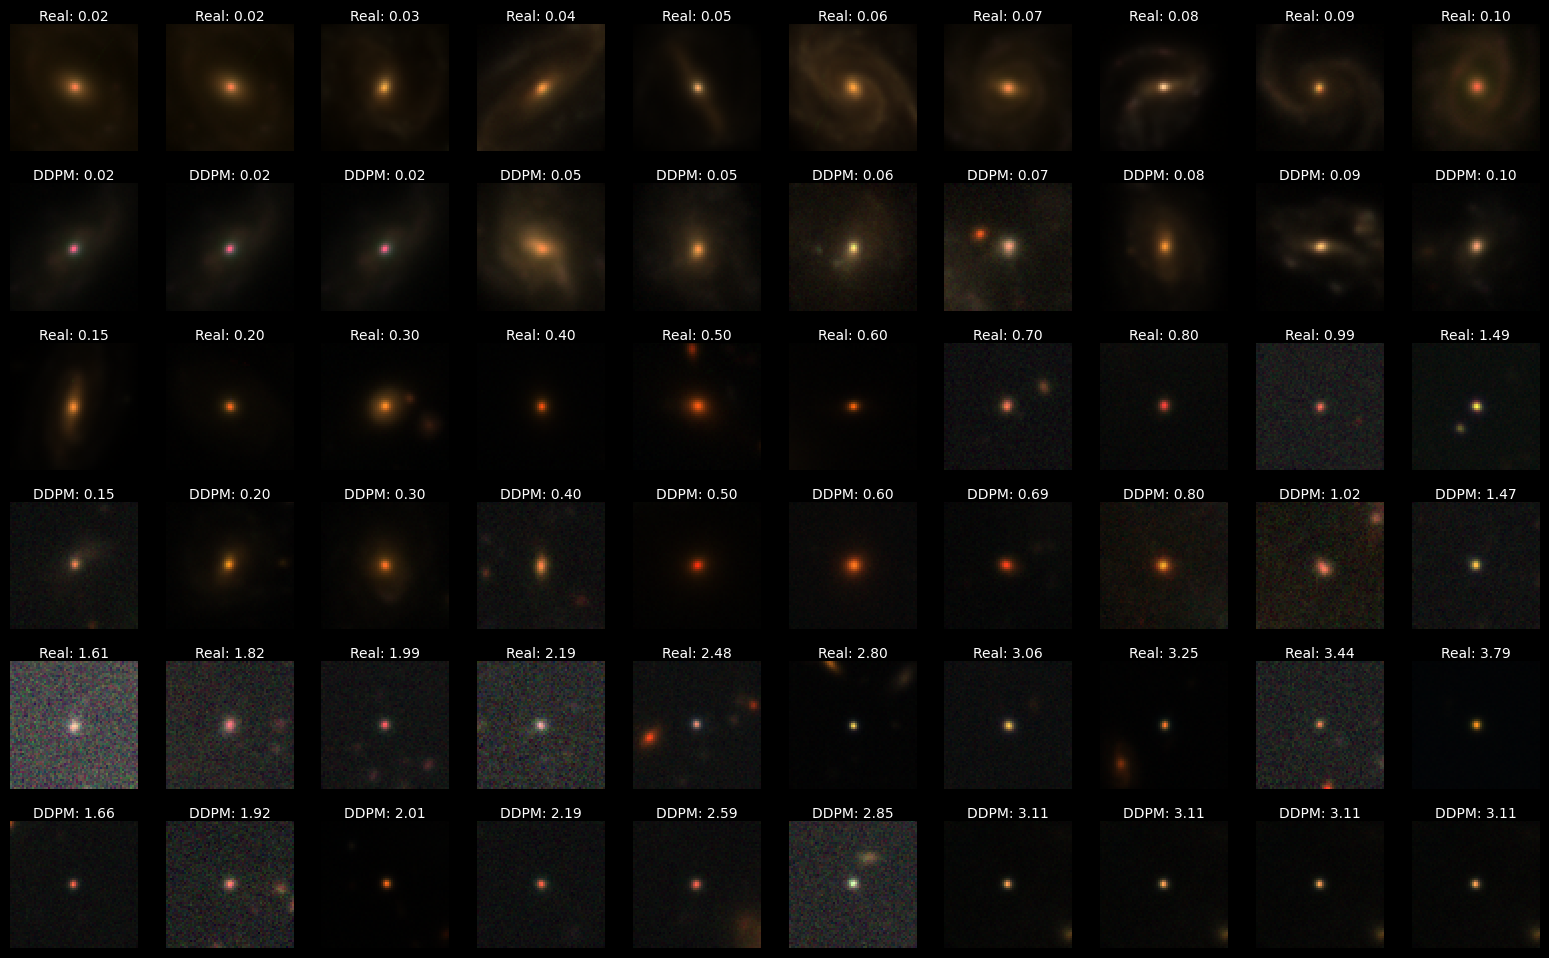

Saved: Metrics/figure6_reproduce.png


In [ ]:
## Figure 6: Real vs Generated — 3 redshift groups × (Real + DDPM) = 6 rows
import glob

GEN_DIR   = '/Users/wen/Desktop/project/lizarraga_2024-main/generated_images'
GEN_Z     = np.load(os.path.join(GEN_DIR, 'generated_redshifts.npy'))
pt_files  = sorted(glob.glob(os.path.join(GEN_DIR, 'generated_image_*.pt')))
TEST_HDF5 = '/Users/wen/Desktop/project/archive/5x64x64_testing_with_morphology.hdf5'  # compare with galaxyML testset

# Group 1: very low-z, galaxies should be largest
target_z_g1 = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.10]
# Group 2: mid-z
target_z_g2 = [0.15, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 1.00, 1.50]
# Group 3: high-z
target_z_g3 = [1.60, 1.80, 2.00, 2.20, 2.50, 2.80, 3.00, 3.20, 3.50, 4.00]

# ── manually override: key = ('g1'/'g2'/'g3', col 0..9) ─────────────────────────
MANUAL_REAL = {}
MANUAL_GEN  = {}
# ─────────────────────────────────────────────────────────────────────────────

def to_rgb(image):
    if isinstance(image, torch.Tensor):
        image = image.numpy()
    rgb = image[[2, 1, 0]].astype(float)
    rgb = np.transpose(rgb, (1, 2, 0))    # g,r,i → i,r,g → R, G, B
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8) # normalize, avoid over exposure and too dark
    return np.clip(rgb, 0, 1)

def score_image(img):
    """ The logic of select galaxy images for comparison.
    Score = SNR × centre × sqrt(extent).
    extent counts pixels above 5% of peak — prefers large extended galaxies."""
    g = img[0].astype(float)   # we use g range to calculate SNR, and the graphs look orange
    peak = g.max()
    snr   = peak / (g.std() + 1e-8)   
    extent = (g > 0.05 * peak).sum()  # the pixel in g band larger than 5% of the peak
    peak_y, peak_x = np.unravel_index(g.argmax(), g.shape)
    dist   = np.sqrt((peak_x - 32)**2 + (peak_y - 32)**2)  # distance of peak to the center
    centre = 1 / (1 + dist / 10)
    return snr, snr * centre * np.sqrt(extent)    #   SNR × centre × √extent, so more spiral and large galaxy can be selected

def find_best_real(all_z, images_ds, target_z, n_candidates=100, min_snr=3.0):
    candidate_idx = np.argsort(np.abs(all_z - target_z))[:n_candidates]
    best_idx, best_score = candidate_idx[0], -1
    for idx in candidate_idx:
        snr, score = score_image(images_ds[idx])
        if snr < min_snr:
            continue
        if score > best_score:
            best_score = score
            best_idx = idx
    return best_idx

def find_best_gen(gen_z, pt_files, target_z, n_candidates=100, min_snr=3.0):
    candidate_idx = np.argsort(np.abs(gen_z - target_z))[:n_candidates]
    best_idx, best_score = candidate_idx[0], -1
    for idx in candidate_idx:
        img = torch.load(pt_files[idx], weights_only=False).numpy()
        snr, score = score_image(img)
        if snr < min_snr:
            continue
        if score > best_score:
            best_score = score
            best_idx = idx
    return best_idx

groups = [('g1', target_z_g1), ('g2', target_z_g2), ('g3', target_z_g3)]

with h5py.File(TEST_HDF5, 'r') as f:
    all_z = f['specz_redshift'][:]
    real_groups = {}
    for gname, tz_list in groups:
        imgs, zfound = [], []
        for ci, tz in enumerate(tz_list):
            midx = MANUAL_REAL.get((gname, ci))
            idx  = midx if midx is not None else find_best_real(all_z, f['image'], tz)
            imgs.append(to_rgb(torch.tensor(f['image'][idx])))
            zfound.append(all_z[idx])
        real_groups[gname] = (imgs, zfound)

gen_groups = {}
for gname, tz_list in groups:
    imgs, zfound = [], []
    for ci, tz in enumerate(tz_list):
        midx = MANUAL_GEN.get((gname, ci))
        idx  = midx if midx is not None else find_best_gen(GEN_Z, pt_files, tz)
        imgs.append(to_rgb(torch.load(pt_files[idx], weights_only=False)))
        zfound.append(GEN_Z[idx])
    gen_groups[gname] = (imgs, zfound)

N = 10
fig, axes = plt.subplots(6, N, figsize=(2*N, 12))
fig.patch.set_facecolor('black')

row_data = [
    (real_groups['g1'], 'Real'),
    (gen_groups['g1'],  'DDPM'),
    (real_groups['g2'], 'Real'),
    (gen_groups['g2'],  'DDPM'),
    (real_groups['g3'], 'Real'),
    (gen_groups['g3'],  'DDPM'),
]

for row_i, ((imgs, zfound), label) in enumerate(row_data):
    for col_i in range(N):
        ax = axes[row_i, col_i]
        ax.imshow(imgs[col_i])
        ax.set_title(f'{label}: {zfound[col_i]:.2f}', color='white', fontsize=10, pad=2)
        ax.axis('off')

plt.subplots_adjust(wspace=0.05, hspace=0.25)
plt.savefig('../Metrics/figures/figure6_reproduce.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()
print("Saved: Metrics/figure6_reproduce.png")

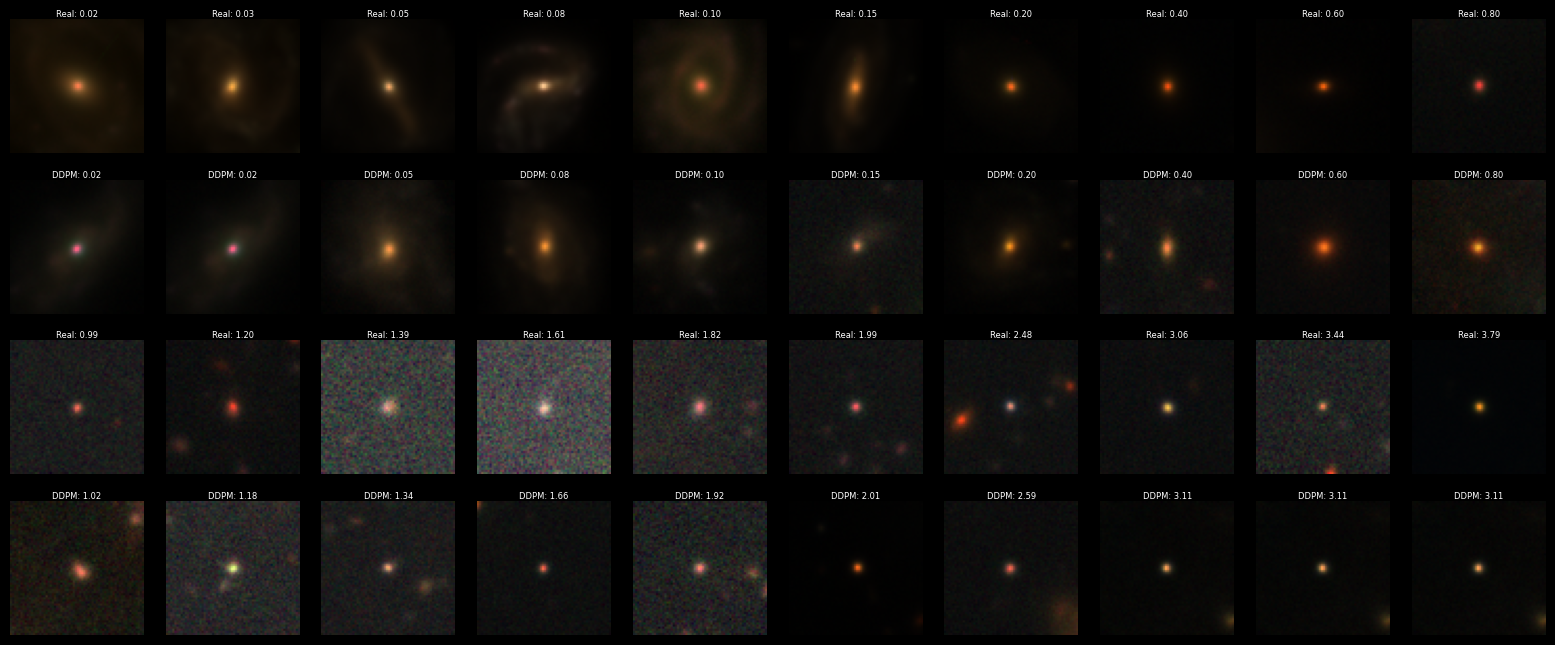

Saved: Metrics/figure6_4row.png


In [ ]:
## Figure 6 (4-row): Real + DDPM × 2 redshift ranges
import glob

GEN_DIR   = '/Users/wen/Desktop/project/lizarraga_2024-main/generated_images'
GEN_Z     = np.load(os.path.join(GEN_DIR, 'generated_redshifts.npy'))
pt_files  = sorted(glob.glob(os.path.join(GEN_DIR, 'generated_image_*.pt')))
TEST_HDF5 = '/Users/wen/Desktop/project/archive/5x64x64_testing_with_morphology.hdf5'

target_z_row1 = [0.01, 0.03, 0.05, 0.08, 0.10, 0.15, 0.20, 0.40, 0.60, 0.80]
target_z_row2 = [1.00, 1.20, 1.40, 1.60, 1.80, 2.00, 2.50, 3.00, 3.50, 4.00]

# ── override: key = ('row1'/'row2', col 0..9) ───────────────────────────
MANUAL_REAL = {}
MANUAL_GEN  = {}
# ─────────────────────────────────────────────────────────────────────────────

def to_rgb(image):
    if isinstance(image, torch.Tensor):
        image = image.numpy()
    rgb = image[[2, 1, 0]].astype(float)
    rgb = np.transpose(rgb, (1, 2, 0))
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
    return np.clip(rgb, 0, 1)

def score_image(img):
    """SNR × centre × sqrt(extent) — prefers extended bright galaxies."""
    g = img[0].astype(float)
    peak   = g.max()
    snr    = peak / (g.std() + 1e-8)
    extent = (g > 0.05 * peak).sum()
    peak_y, peak_x = np.unravel_index(g.argmax(), g.shape)
    dist   = np.sqrt((peak_x - 32)**2 + (peak_y - 32)**2)
    centre = 1 / (1 + dist / 10)
    return snr, snr * centre * np.sqrt(extent)

def find_best_real(all_z, images_ds, target_z, n_candidates=100, min_snr=3.0):
    cand = np.argsort(np.abs(all_z - target_z))[:n_candidates]
    best_idx, best_score = cand[0], -1
    for idx in cand:
        snr, score = score_image(images_ds[idx])
        if snr >= min_snr and score > best_score:
            best_score = score
            best_idx = idx
    return best_idx

def find_best_gen(gen_z, pt_files, target_z, n_candidates=100, min_snr=3.0):
    cand = np.argsort(np.abs(gen_z - target_z))[:n_candidates]
    best_idx, best_score = cand[0], -1
    for idx in cand:
        img = torch.load(pt_files[idx], weights_only=False).numpy()
        snr, score = score_image(img)
        if snr >= min_snr and score > best_score:
            best_score = score
            best_idx = idx
    return best_idx

with h5py.File(TEST_HDF5, 'r') as f:
    all_z = f['specz_redshift'][:]
    real_rows = {}
    for rname, tz_list in [('row1', target_z_row1), ('row2', target_z_row2)]:
        imgs, zfound = [], []
        for ci, tz in enumerate(tz_list):
            midx = MANUAL_REAL.get((rname, ci))
            idx  = midx if midx is not None else find_best_real(all_z, f['image'], tz)
            imgs.append(to_rgb(torch.tensor(f['image'][idx])))
            zfound.append(all_z[idx])
        real_rows[rname] = (imgs, zfound)

gen_rows = {}
for rname, tz_list in [('row1', target_z_row1), ('row2', target_z_row2)]:
    imgs, zfound = [], []
    for ci, tz in enumerate(tz_list):
        midx = MANUAL_GEN.get((rname, ci))
        idx  = midx if midx is not None else find_best_gen(GEN_Z, pt_files, tz)
        imgs.append(to_rgb(torch.load(pt_files[idx], weights_only=False)))
        zfound.append(GEN_Z[idx])
    gen_rows[rname] = (imgs, zfound)

N = 10
fig, axes = plt.subplots(4, N, figsize=(2*N, 8))
fig.patch.set_facecolor('black')

for row_i, ((imgs, zfound), label) in enumerate([
    (real_rows['row1'], 'Real'),
    (gen_rows['row1'],  'DDPM'),
    (real_rows['row2'], 'Real'),
    (gen_rows['row2'],  'DDPM'),
]):
    for col_i in range(N):
        ax = axes[row_i, col_i]
        ax.imshow(imgs[col_i])
        ax.set_title(f'{label}: {zfound[col_i]:.2f}', color='white', fontsize=6, pad=2)
        ax.axis('off')

plt.subplots_adjust(wspace=0.05, hspace=0.2)
plt.savefig('../Metrics/figures/figure6_4row.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()
print("Saved: Metrics/figure6_4row.png")

In [ ]:
## Preview: σ=1.0 model quality check (10 images, local)
# Make sure best_model.pth is downloaded first:
#   mkdir -p ../Training/Model_Checkpoints_s10
#   scp ws452@login.hpc.cam.ac.uk:.../Model_Checkpoints_s10/best_model.pth ../Training/Model_Checkpoints_s10/

SIGMA_TAG = '10'   # ← '01'=σ=0.1  '05'=σ=0.5  '10'=σ=1.0
CKPT_PATH = f'../Training/Model_Checkpoints_s{SIGMA_TAG}/best_model.pth'

import os
if not os.path.exists(CKPT_PATH):
    print(f"Checkpoint not found: {CKPT_PATH}")
    print("Download from CSD3 first:")
    print(f"  mkdir -p ../Training/Model_Checkpoints_s{SIGMA_TAG}")
    print(f"  scp ws452@login.hpc.cam.ac.uk:/rds/user/ws452/hpc-work/lizarraga_2024/code/Model_Checkpoints_s{SIGMA_TAG}/best_model.pth ../Training/Model_Checkpoints_s{SIGMA_TAG}/")
else:
    # load model
    model_preview = UNet_conditional_conv(c_in=5, c_out=5, time_dim=256, y_dim=1).to(args.device)
    ckpt_preview  = torch.load(CKPT_PATH, map_location=args.device, weights_only=False)
    model_preview.load_state_dict(ckpt_preview['model_state_dict'])
    ema_preview   = EMA(model_preview, beta=0.995)
    if 'ema_state_dict' in ckpt_preview:
        ema_preview.load_state_dict(ckpt_preview['ema_state_dict'])
    ema_model_preview = ema_preview.get_ema_model()
    print(f"Loaded σ={SIGMA_TAG} from {CKPT_PATH}")

    # Diffusion (reuse the Diffusion class defined above)
    diff_preview = Diffusion(noise_steps=args.noise_steps,
                             beta_start=args.beta_start,
                             beta_end=args.beta_end,
                             img_size=args.image_size,
                             device=args.device)

    # 10 images, evenly spaced over z=0.1-3.5
    N_PREV = 10
    preview_z = torch.linspace(0.1, 3.5, N_PREV).unsqueeze(1).to(args.device)
    print(f"Generating {N_PREV} images on {args.device}  (CPU ~5-10 min)...")

    with torch.no_grad():
        imgs_prev = diff_preview.sample_images(ema_model_preview, N_PREV, preview_z)

    def to_rgb_prev(img):
        if isinstance(img, torch.Tensor):
            img = img.numpy()
        rgb = img[[2, 1, 0]].astype(float)
        rgb = np.transpose(rgb, (1, 2, 0))
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
        return np.clip(rgb, 0, 1)

    fig, axes = plt.subplots(1, N_PREV, figsize=(N_PREV * 2, 2.5))
    fig.patch.set_facecolor('black')
    for i in range(N_PREV):
        axes[i].imshow(to_rgb_prev(imgs_prev[i]))
        axes[i].set_title(f'z={preview_z[i,0].item():.2f}', color='white', fontsize=8)
        axes[i].axis('off')
    plt.suptitle(f'σ={SIGMA_TAG} model — {N_PREV} preview images', color='white', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'../Metrics/figures/preview_s{SIGMA_TAG}.png', dpi=150, bbox_inches='tight', facecolor='black')
    plt.show()
    print(f"Saved: Metrics/preview_s{SIGMA_TAG}.png")

#### Generated galaxy colour evolution by redshift bin (same code as dataset_analysis)

Loading all generated images...
Loaded: (10000, 5, 64, 64)


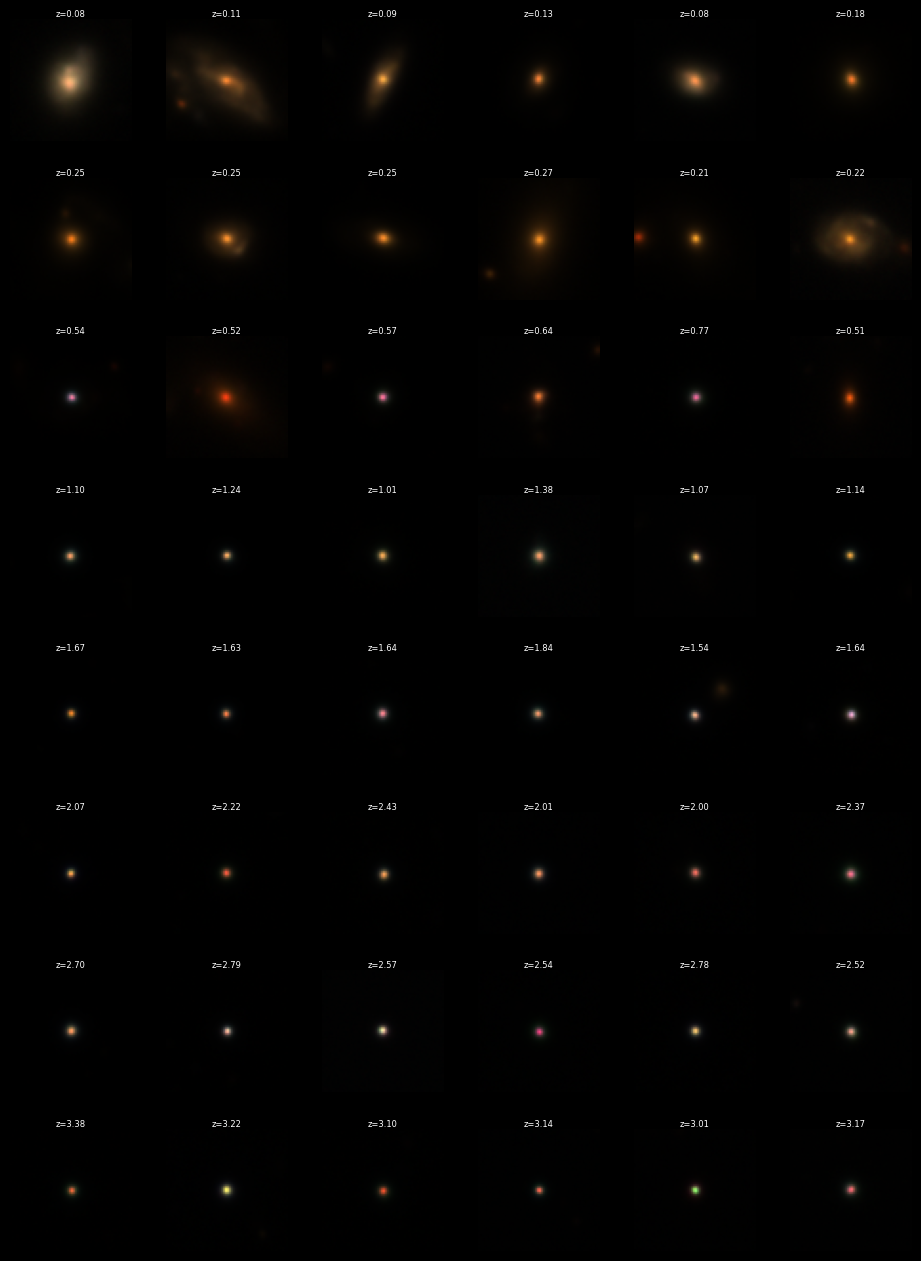

Saved: generated_colour_evolution.png


In [ ]:
## Generated galaxy colour evolution by redshift bin (same code as dataset_analysis)
import glob, os
import numpy as np
import torch
import matplotlib.pyplot as plt

GEN_DIR  = '/Users/wen/Desktop/project/lizarraga_2024-main/generated_images'
z        = np.load(os.path.join(GEN_DIR, 'generated_redshifts.npy'))
pt_files = sorted(glob.glob(os.path.join(GEN_DIR, 'generated_image_*.pt')))

print("Loading all generated images...")
images = np.stack([torch.load(f, weights_only=False).numpy() for f in pt_files])

# Use centre 20×20 region flux as proxy for i_cmodel_mag (avoids neighbour contamination)
# i_cmodel_mag in real data = model-fitted flux of central target only, not neighbours
i_mag = -images[:, 2, 22:42, 22:42].sum(axis=(1, 2))   # negate: smaller = brighter
print(f"Loaded: {images.shape}")

# ── image strip across z bins (copied from dataset_analysis) ─────────────────
def to_rgb(img):
    """i→R, r→G, g→B, linear stretch"""
    rgb = img[[2, 1, 0]].astype(float)
    rgb = np.transpose(rgb, (1, 2, 0))
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
    return np.clip(rgb, 0, 1)

Z_BINS    = [(0.0, 0.2), (0.2, 0.5), (0.5, 1.0), (1.0, 1.5),
             (1.5, 2.0), (2.0, 2.5), (2.5, 3.0), (3.0, 4.0)]
N_PER_BIN = 6

fig, axes = plt.subplots(len(Z_BINS), N_PER_BIN, figsize=(N_PER_BIN*2, len(Z_BINS)*2))
fig.patch.set_facecolor('black')

for row_i, (zlo, zhi) in enumerate(Z_BINS):
    bin_idx = np.where((z >= zlo) & (z < zhi))[0]
    # pick brightest-i galaxies (smallest i_mag value)
    brightest = bin_idx[np.argsort(i_mag[bin_idx])[:N_PER_BIN*3]]   # brightest in i-band
    chosen = brightest[:N_PER_BIN]
    for col_i in range(N_PER_BIN):
        ax = axes[row_i, col_i]
        if col_i < len(chosen):
            ax.imshow(to_rgb(images[chosen[col_i]]))
            ax.set_title(f'z={z[chosen[col_i]]:.2f}', color='white', fontsize=6, pad=1)
        ax.axis('off')
    axes[row_i, 0].set_ylabel(f'z {zlo}-{zhi}', color='white', fontsize=8)

plt.subplots_adjust(wspace=0.04, hspace=0.3)
plt.savefig('../Metrics/figures/generated_colour_evolution.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()
print("Saved: generated_colour_evolution.png")

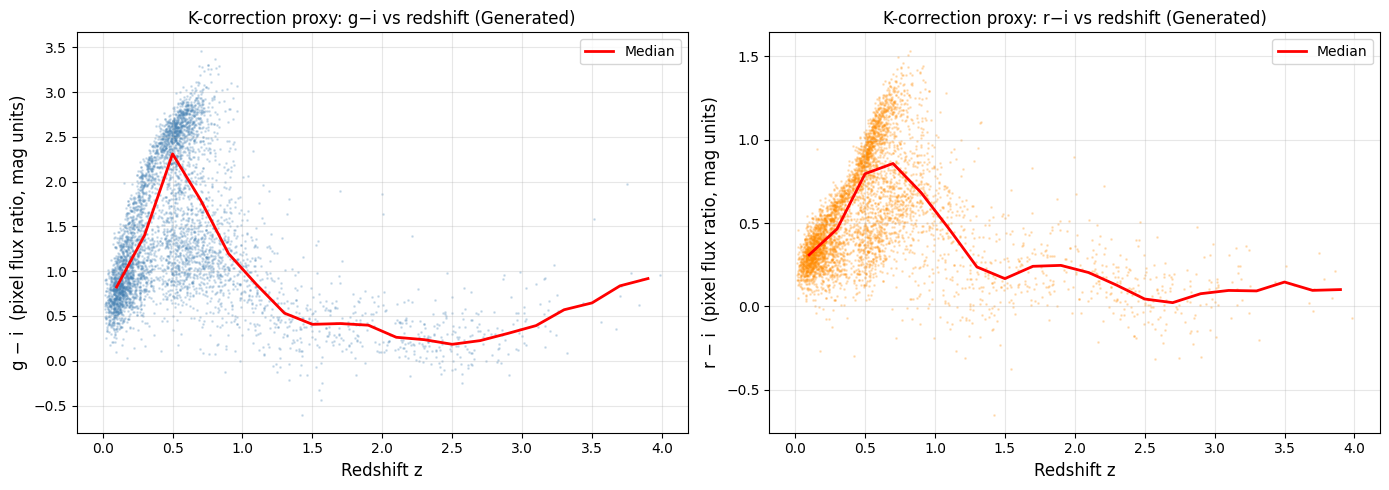

Saved: generated_colour_vs_redshift.png


In [ ]:
## K-correction proxy: g−i and r−i colour vs redshift (generated images)
# Same structure as dataset_analysis 1A
# Colour index from pixel flux: g-i = -2.5*log10(g_flux/i_flux)
# Real data uses i_cmodel_mag differences; here we use centre-region pixel sums

import numpy as np
import matplotlib.pyplot as plt

# Use centre 20×20 to avoid neighbour contamination
g_flux = images[:, 0, 22:42, 22:42].sum(axis=(1, 2)).astype(float)
r_flux = images[:, 1, 22:42, 22:42].sum(axis=(1, 2)).astype(float)
i_flux = images[:, 2, 22:42, 22:42].sum(axis=(1, 2)).astype(float)

eps = 1e-8
g_mag_p = -2.5 * np.log10(g_flux + eps)
r_mag_p = -2.5 * np.log10(r_flux + eps)
i_mag_p = -2.5 * np.log10(i_flux + eps)

gi = g_mag_p - i_mag_p
ri = r_mag_p - i_mag_p

mask = (gi > -6) & (gi < 6) & (z < 4.0) & (i_flux > 0.01)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

idx_sub = np.random.choice(np.where(mask)[0], min(5000, mask.sum()), replace=False)
axes[0].scatter(z[idx_sub], gi[idx_sub], s=1, alpha=0.2, color='steelblue')
z_bins = np.arange(0, 4.1, 0.2)
bin_centers = 0.5 * (z_bins[:-1] + z_bins[1:])
medians = [np.median(gi[mask & (z >= lo) & (z < hi)])
           for lo, hi in zip(z_bins[:-1], z_bins[1:])]
axes[0].plot(bin_centers, medians, 'r-', linewidth=2, label='Median')
axes[0].set_xlabel('Redshift z', fontsize=12)
axes[0].set_ylabel('g − i  (pixel flux ratio, mag units)', fontsize=12)
axes[0].set_title('K-correction proxy: g−i vs redshift (Generated)', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(z[idx_sub], ri[idx_sub], s=1, alpha=0.2, color='darkorange')
medians_ri = [np.median(ri[mask & (z >= lo) & (z < hi)])
              for lo, hi in zip(z_bins[:-1], z_bins[1:])]
axes[1].plot(bin_centers, medians_ri, 'r-', linewidth=2, label='Median')
axes[1].set_xlabel('Redshift z', fontsize=12)
axes[1].set_ylabel('r − i  (pixel flux ratio, mag units)', fontsize=12)
axes[1].set_title('K-correction proxy: r−i vs redshift (Generated)', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../Metrics/figures/generated_colour_vs_redshift.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: generated_colour_vs_redshift.png")

In [33]:
import sys
print(sys.executable)
!{sys.executable} -m pip show sep


/Users/wen/astro/bin/python
